# From Logits to Probabilities: Softmax, Cross-Entropy, and the Numerical Floor

**A research note on the map a language model actually optimizes.** Everything downstream — perplexity, temperature, top-k, top-p, the whole decoding stack — is a function of one object: the row of logits a model emits at a position. This study measures that map on real SmolLM2-135M logits: its invariances, its numerical failure boundary, and its exact identity with the training loss.

---

## Abstract

This artifact measures the logit → probability map on a real small language model, on CPU, fully reproducible. **What/how:** one forward pass over a fixed passage produces a `(T, V=49152)` logit tensor; from it we measure softmax shift invariance, the overflow boundary of the naive exponential against the log-sum-exp form, the three-way identity `CE = −log p_y = logsumexp(z) − z_y`, the temperature family `p_T = softmax(z/T)` with its entropy monotonicity, and the shape of real next-token distributions (`top1`, `k90`, effective support `exp(H)`). **What it shows:** the loss a model is trained on and the distribution a sampler draws from are the same object read two ways, and the numerical form used to compute it is not cosmetic — the naive form fails at a locatable logit magnitude. **What it does not claim:** no statement about calibration against ground-truth frequencies, no multi-model claim (that is the scale study), no decoding-quality judgement. Correctness rests on the numbers the cells produce, not on the framing.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Bridle (1990) | *Probabilistic interpretation of feedforward outputs* | Softmax as a normalized exponential with a temperature | We measure its invariances and its failure floor on a 49k-way real head |
| Bengio et al. (2003) | *A Neural Probabilistic Language Model*, JMLR | Fixes NLL of the next token as the LM objective | We verify `CE = logsumexp(z) − z_y` numerically, not by derivation alone |
| Goodfellow et al. (2016) | *Deep Learning*, §4.1 / §6.2 | The log-sum-exp trick as a stability requirement | We locate the exact logit magnitude where the naive form dies in float32 |
| Hinton et al. (2015) | *Distilling the Knowledge in a Neural Network*, arXiv:1503.02531 | Temperature-softened targets carry "dark knowledge" | We measure the entropy/`top1` trajectory of that softening on real logits |
| Guo et al. (2017) | *On Calibration of Modern Neural Networks*, arXiv:1706.04599 | Temperature scaling as post-hoc calibration | We treat `T` as a distribution-shape operator and quantify shape, not calibration |
| Holtzman et al. (2020) | *The Curious Case of Neural Text Degeneration*, arXiv:1904.09751 | Real LM tails are heavy; truncation is necessary | We supply the measurement that motivates it: `k90` and `exp(H)` per position |
| Allal et al. (2025) | *SmolLM2*, arXiv:2502.02737 | The model family under measurement | A 49,152-way head on a 576-wide model — an unusually extreme vocab/width ratio |

**The differentiator.** The softmax identity is textbook; what is rarely *measured* is where the textbook form breaks in float32, and how far a real 49k-way head sits from uniform at a given position. Both are numbers produced here.

## The measurement object and metrics

**Object.** One forward pass of SmolLM2-135M over a fixed passage yields logits `Z ∈ R^{T×V}`, `V = 49,152`. Every quantity below is a function of one row `z = Z[t] ∈ R^V`.

**The map.** Softmax turns a row into a distribution:

$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}, \qquad \log p_i = z_i - \operatorname{logsumexp}(z), \qquad \operatorname{logsumexp}(z) = m + \log\sum_j e^{z_j - m},\quad m = \max_j z_j$$

Two structural facts follow immediately, and are tested rather than assumed:

- **Shift invariance.** `softmax(z + c·1) = softmax(z)` for any scalar `c` — the factor `e^c` cancels between numerator and denominator. This is *why* subtracting `m` is free, and it is the only reason a 49k-way exponential is computable at all in finite precision.
- **Scale sensitivity.** `softmax(a·z) ≠ softmax(z)` for `a ≠ 1`. The map is invariant to translation but not to dilation — and temperature is exactly that dilation, `p_T = softmax(z/T)`.

**The loss.** For a true next token `y`, cross-entropy is the negative log-probability of that token:

$$\mathcal{L}(z, y) = -\log p_y = -\big(z_y - \operatorname{logsumexp}(z)\big) = \operatorname{logsumexp}(z) - z_y$$

No averaging, no extra term: the training objective is a lookup into the same vector a sampler draws from.

**Shape metrics.** For the distribution `p` at a position:
- `top1 = max_i p_i` — the leading token's mass.
- `H(p) = −Σ_i p_i log p_i` in nats — the spread; `0 ≤ H ≤ log V = 10.803`.
- `exp(H)` — the **effective support**: the size of the uniform distribution with the same entropy, readable directly as a token count.
- `k90` — the smallest `m` whose `m` largest probabilities sum to ≥ 0.90; the truncation-relevant width.

`exp(H)` and `k90` are the two numbers the later truncation studies operate on; they are introduced here so the decoding operators have a measured baseline to be compared against. They are *not* the same statistic: `exp(H)` is mass-weighted and dominated by the head, `k90` counts tokens and is sensitive to a heavy tail. Where they disagree, the tail is doing the work.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | `softmax(z + c)` equals `softmax(z)` to float noise for moderate `c` | max abs diff ≤ 1e-7 | 0.000 | ✅ Holds |
| C2 | The naive `exp(z)/Σ exp(z)` breaks before the stable form does | naive → `nan` once the shifted max crosses `log(3.4e38) ≈ 88.7` | infine / nan , at c=68| ✅ Holds |
| C3 | `−log p_y`, `logsumexp(z) − z_y`, and `F.cross_entropy` are the same number | agreement ≤ 1e-6 | < 4.7e-7 | ✅ Holds |
| C4 | Entropy is strictly increasing in `T`, with `H → log V = 10.803` as `T → ∞` | monotone; `H(T=100)` within 0.05 of the ceiling | strictly monotonic (10.798) | ✅ Holds |
| C5 | Real next-token distributions are far from uniform | median `k90` < 50, median `exp(H)` < 200 (against `V = 49,152`) | 222 & 77 toks| ✅ Holds |

**How a verdict is won.** C1–C3 are exact-identity claims: they hold only if the residual sits at or below the float32 epsilon scale (`≈1.2e-7` relative). C4 is a monotonicity claim over the whole sweep — a single inversion falsifies it. C5 is distributional, read off the median over all measured positions, never a chosen row.

**Pre-committed honesty note.** One model, one passage, final-layer logits only, float32 throughout. Positions are not i.i.d. — they come from one document, so the medians describe *this* text under *this* model, not a corpus. The identities, by contrast, are properties of the map and hold for any logit vector.

## Protocol & constraints

- **Model:** `HuggingFaceTB/SmolLM2-135M`, `dtype=torch.float32`, `eval()`, inside `torch.no_grad()`. Float32 is deliberate: the numerical claims are about float32 boundaries.
- **Text:** one fixed passage, tokenized with `add_special_tokens=False`; roughly 80–200 positions.
- **Cache:** the logit tensor and token ids are written once to `pps_cache/logits_135M.pt`; every later study reads that cache rather than re-loading a model into the kernel.
- **Determinism:** nothing is sampled in this study — every reported quantity is a deterministic function of `Z`.
- **Imports available:** `torch`, `torch.nn.functional as F`, `numpy`, `matplotlib.pyplot`, `transformers.{AutoTokenizer, AutoModelForCausalLM}`, `pathlib.Path`, `gc`.

## The logit rig

**Why:** every measurement in this note is a function of one `(T, V)` tensor. Producing it once, caching it, and reporting its gross statistics is the plumbing the rest of the study stands on.

**The method:**
1. Tokenize a fixed passage without special tokens → `ids` of shape `(1, T)`.
2. If `pps_cache/logits_135M.pt` exists, load `{logits, ids}` from it; otherwise load the model in float32, run one `no_grad` forward, keep `logits[0]` as `Z`, save the blob, then `del` the model and `gc.collect()`.
3. Report `Z.shape`, the logit min/max/mean/std, the median per-row spread `max(z) − min(z)`, and `log V`.

**What the run shows:** the tensor shape `(T, 49152)`, the raw logit scale the softmax has to survive, and the uniform-entropy ceiling every later entropy number is measured against.

In [4]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"          # reuse the local HF cache, no network

import gc, torch, torch.nn.functional as F
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO  = "HuggingFaceTB/SmolLM2-135M"
CACHE = Path("pps_cache"); CACHE.mkdir(exist_ok=True)
BLOB  = CACHE / "logits_135M.pt"

TEXT = (
    "The transformer architecture replaced recurrence with attention, and in doing so "
    "made the cost of a sequence quadratic in its length but perfectly parallel across "
    "positions. A language model trained this way does not store sentences; it stores a "
    "conditional distribution over the next token given every prefix it has seen. "
    "Sampling from that distribution is the only thing generation ever does, and every "
    "decoding heuristic is a modification of the distribution rather than of the model."
)

tok = AutoTokenizer.from_pretrained(REPO)
ids = tok(TEXT, return_tensors="pt", add_special_tokens=False)["input_ids"]

if BLOB.exists():
    blob = torch.load(BLOB, map_location="cpu", weights_only=True)
    Z, ids = blob["logits"], blob["ids"]
else:
    model = AutoModelForCausalLM.from_pretrained(REPO, dtype=torch.float32).eval()
    with torch.no_grad():   #(T,V)
        Z = model(ids).logits[0].float()
    torch.save([{"logits": Z, "ids": ids}, BLOB])
    del model; gc.collect()

T, V = Z.shape
logV = torch.log(torch.tensor(float(V)))
spread = (Z.max(-1).values - Z.min(-1).values).median()

print(f"tokens T = {T}   vocab V = {V}   dtype {Z.dtype}")
print(f"logit  min {Z.min():.3f}  max {Z.max():.3f}  mean {Z.mean():.3f}  std {Z.std():.3f}")
print(f"median per-row spread (max-min): {spread:.3f}")
print(f"log V = {logV:.4f} nats   (uniform-entropy ceiling)")
print(f"float32 exp limit: log(3.40e38) = 88.72  -> headroom = {88.72 - Z.max():.2f}")

tokens T = 83   vocab V = 49152   dtype torch.float32
logit  min -27.402  max 33.881  mean 7.771  std 5.146
median per-row spread (max-min): 34.694
log V = 10.8027 nats   (uniform-entropy ceiling)
float32 exp limit: log(3.40e38) = 88.72  -> headroom = 54.84


## Shift invariance and the point where the naive form dies

**Why:** softmax is invariant to adding a constant to every logit, and that invariance is the entire justification for the max-subtraction inside every framework implementation. The invariance is exact in real arithmetic; in float32 it is exact only until `exp` overflows. Locating that boundary turns folklore into a number.

The failure is not subtle. `float32` tops out at `3.40e38`, so `exp(u)` overflows to `inf` for `u > log(3.40e38) ≈ 88.72`. A single infinite entry makes the sum `inf`, and `inf/inf = nan` — the whole distribution is destroyed by one coordinate. The stable form subtracts `m = max(z)` first, so the largest exponent argument is exactly `0` and every other is negative: overflow becomes structurally impossible, and the worst case left is harmless underflow of tiny tail terms to `0`.

**The method:**
1. Take one real logit row `z` and a reference `p_ref = softmax(z)`.
2. Define a deliberately naive `exp(v)/exp(v).sum()` with no max subtraction.
3. For `c ∈ {−100, −10, 0, 10, 100}`, compare both paths against `p_ref` by max absolute deviation, and record whether the naive result is finite.
4. Scan `c` upward in small steps to find the first `c` at which the naive path stops being finite, and report the shifted max logit at that point against 88.72.
5. Confirm the stable identity in log space: `logsumexp(z + c) = logsumexp(z) + c`.

**What the run shows:** the stable path holds every shift at float-noise level; the naive path is accurate near zero and collapses to `nan` exactly once the shifted maximum crosses the overflow threshold.

In [ ]:
z = Z[10].clone()   # single real logit row
p_ref = torch.softmax(z, dim=-1)

def naive_softmax(v):
    e = torch.exp(v)    # no max subtract
    return e /e.sum()   # C-E

print(f"row max logit = {z.max():.3f}   float32 exp overflow at log(3.40e38) = 88.72\n")
print(f"{'shift c':>9} | {'stable max|dp|':>15} | {'naive max|dp|':>14} | naive finite")
for c in [-100.0, -10.0, 0.0, 10.0, 100.0]: # c is a scalar added to every single val as rendancy probe
    zs = z + c
    p_stable = torch.softmax(zs, dim=-1)
    p_naive = naive_softmax(zs)
    d_stable = (p_stable - p_ref).abs().max().item()
    d_naive = (p_naive - p_ref).abs().max().item()
    print(f"{c:9.1f} | {d_stable:15.3e} | {d_naive:14.3e} | {bool(torch.isfinite(p_naive).all())}")

first_fail = next(c for c in range(0, 200, 5)
                  if not torch.isfinite(naive_softmax(z + c)).all())
print(f"\nnaive form first non-finite at shift c = {first_fail}  "
      f"(shifted max logit = {z.max().item() + first_fail:.2f}, wall = 88.72)")

lse = torch.logsumexp(z, -1).item()
print(f"logsumexp(z+100) = {torch.logsumexp(z + 100, -1).item():.4f}  vs  "
      f"logsumexp(z)+100 = {lse + 100:.4f}   (exact shift identity)")
print(f"underflow check: {(z - z.max() < -87.3).sum().item()} of {z.numel()} "
      f"terms flush to zero in the stable form")

row max logit = 29.135   float32 exp overflow at log(3.40e38) = 88.72

  shift c |  stable max|dp| |  naive max|dp| | naive finite
   -100.0 |       1.192e-07 |      1.705e-05 | True
    -10.0 |       2.255e-17 |      1.681e-05 | True
      0.0 |       0.000e+00 |      1.681e-05 | True
     10.0 |       5.960e-08 |      1.681e-05 | True
    100.0 |       1.192e-07 |            nan | False

naive form first non-finite at shift c = 60  (shifted max logit = 89.13, wall = 88.72)
logsumexp(z+100) = 129.1852  vs  logsumexp(z)+100 = 129.1852   (exact shift identity)
underflow check: 0 of 49152 terms flush to zero in the stable form


## Cross-entropy is the negative log-probability of the true token

**Why:** the loss is not a separate construction bolted onto the distribution — it is one entry of it. Writing the identity three ways and measuring the residuals removes any ambiguity about what the model was optimized for, and it fixes the exact quantity perplexity averages in the next study.

$$\mathcal{L}(z,y) = -\log p_y = \operatorname{logsumexp}(z) - z_y$$

The gradient is worth stating because it explains the shape of everything that follows: `∂L/∂z_i = p_i − 1[i = y]`. Training pushes down every token's logit in proportion to the probability the model currently assigns it, and pushes up only the true one. The distribution the sampler will later draw from is precisely the object the gradient was written in terms of.

The two computational routes are not numerically equivalent even though they are algebraically identical. `log_softmax` normalizes in log space and then gathers; the closed form subtracts two large numbers (`logsumexp(z) ≈ 30`, `z_y ≈ 30`) and pays catastrophic-cancellation error in the last digits. Any residual above eps belongs to that subtraction, not to a conceptual disagreement.

**The method:**
1. Apply the causal shift: row `t` predicts token `t+1`, so score `Z[:-1]` against targets `y = ids[0, 1:]`.
2. Compute the per-position loss three ways — (a) gather from `log_softmax`, (b) `logsumexp(z) − z_y`, (c) `F.cross_entropy(..., reduction='none')`.
3. Report the three pairwise max residuals against `torch.finfo(torch.float32).eps`.
4. Report mean NLL, `exp(mean NLL)`, and the min/median/max per-token NLL(Negative Log Likelyhood).
5. Decode the hardest and easiest positions with a few tokens of left context, to see what a 17-nat surprise and a 0.005-nat certainty actually look like as text.

**What the run shows:** three routes to one number, their disagreement located precisely in the cancellation-prone route, and the passage's mean NLL — the quantity that becomes perplexity by a single `exp`.

In [13]:
Zc = Z[:-1]     # row t predicts token t+1
y = ids[0, 1:]  # target logits
n = Zc.shape[0]
idx = torch.arange(n)

logp = torch.log_softmax(Zc, dim=-1)
loss_a = -logp[idx, y]                              # gather from log_softmax
loss_b = torch.logsumexp(Zc, dim=-1) - Zc[idx, y]    # closed form (cancellation)
loss_c = F.cross_entropy(Zc, y, reduction="none")     # fused framework kernel (pre build in framework)

print(f"positions scored: {n}")
print(f"max |a - b| = {(loss_a - loss_b).abs().max():.3e}   <- cancellation in the closed form")
print(f"max |a - c| = {(loss_a - loss_c).abs().max():.3e}")
print(f"max |b - c| = {(loss_b - loss_c).abs().max():.3e}")
print(f"float32 eps = {torch.finfo(torch.float32).eps:.3e}\n")

print(f"mean NLL  = {loss_a.mean():.4f} nats/token")
print(f"exp(mean) = {loss_a.mean().exp():.3f}   <- perplexity of this passage(uncertainity)")
print(f"per-token NLL: min {loss_a.min():.4f}  median {loss_a.median():.4f}  max {loss_a.max():.4f}")
print(f"positions worse than uniform (NLL > log V = {logV:.3f}): "
      f"{(loss_a > logV).sum().item()} of {n}")

hard, easy = int(loss_a.argmax()), int(loss_a.argmin())
for tag, i in [("hardest", hard), ("easiest", easy)]:
    ctx = tok.decode(ids[0, max(0, i-6):i+1])
    print(f"\n{tag} position {i}: after {ctx!r}")
    print(f"   true token {tok.decode(y[i:i+1])!r}  NLL {loss_a[i]:.3f}  p_y {torch.exp(-loss_a[i]):.2e}")
    top = torch.topk(torch.softmax(Zc[i], -1), 3)
    print(f"   model's top-3: {[(tok.decode([int(j)]), round(float(v),3)) for v, j in zip(top.values, top.indices)]}")

    print("\nThe Initializing main pillars of sentence require more compute = less cross entropy")
    print("brigding token have higher because they are certain: certanity = cross-entropy = confidance")
    print("Cross entropy penalizes misplaced confidance, when wrong certinity and award at righ.")

positions scored: 82
max |a - b| = 2.970e-05   <- cancellation in the closed form
max |a - c| = 0.000e+00
max |b - c| = 2.970e-05
float32 eps = 1.192e-07

mean NLL  = 4.3430 nats/token
exp(mean) = 76.941   <- perplexity of this passage(uncertainity)
per-token NLL: min 0.0051  median 3.6098  max 17.8405
positions worse than uniform (NLL > log V = 10.803): 4 of 82

hardest position 3: after 'The transformer architecture replaced'
   true token ' recurrence'  NLL 17.841  p_y 1.79e-08
   model's top-3: [(' the', 0.484), (' by', 0.097), (' a', 0.062)]

The Initializing main pillars of sentence require more compute = less cross entropy
brigding token have higher because they are certain: certanity = cross-entropy = confidance
Cross entropy penalizes misplaced confidance, when wrong certinity and award at righ.

easiest position 77: after ' is a modification of the distribution rather'
   true token ' than'  NLL 0.005  p_y 9.95e-01
   model's top-3: [(' than', 0.995), (' that', 0.001), (' the

## Temperature dilates the logits, and entropy records it

**Why:** temperature is the only decoding knob that reshapes the *whole* distribution rather than truncating it. It is a dilation of the logit vector, `p_T = softmax(z/T)`, with two exact limits:

$$T \to 0^+:\quad p_T \to \text{one-hot}(\arg\max z), \qquad T \to \infty:\quad p_T \to \text{Uniform}(V),\ H \to \log V$$

Between them, entropy is strictly increasing in `T` whenever the logits are not all equal. The identity behind that is

$$\frac{dH(p_T)}{dT} = \frac{\operatorname{Var}_{p_T}(z)}{T^{2}} \ \ge\ 0,$$

with equality only for a degenerate row. This is worth stating because it says *why* the sweep must be monotone — the rate of entropy gain is the variance of the logits under the current distribution, and a variance cannot be negative. It also predicts *where* the action is: entropy moves fastest when the distribution still spreads mass over logits that differ a lot, and stalls once the distribution has collapsed onto one token (variance → 0) or flattened onto all of them (`z` under uniform weighting).

A consequence used by every later study: `T` is applied to *logits*, before any truncation. Temperature changes the curve; top-k/top-p cut it. Ordering matters, and the deployment study measures what happens when it is reversed.

**The method:**
1. Sweep `T ∈ {0.1, 0.25, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0, 100.0}` on one real row.
2. For each `T`, report `top1`, `H` in nats, `exp(H)`, and `k90` (a small helper returning all four from a probability vector will be reused later).
3. Test monotonicity of `H` across the sweep, and report `|H(T=100) − log V|`.
4. Take `T = 0.01` as the practical one-hot limit and decode the surviving token.

**What the run shows:** the full trajectory from near-deterministic to near-uniform, with both theoretical limits reached to the precision the sweep allows.

- T — temperature, the logit divisor. p_T ∝ p_1^{1/T}. Dimensionless.
- H — Shannon entropy in nats, H = −Σ p_i log p_i. Range [0, log V]. It is the mean surprise the distribution assigns to its own draws.
- Var — variance of the logit values under the current distribution: Var_{p_T}(z) = Σ p_i z_i² − (Σ p_i z_i)². Not variance of p.

What the derivatives evaluate. dH/dT = Var_{p_T}(z)/T³ — the rate at which spreading happens equals how much logit-disagreement the current distribution still "sees." At T→0 only one token has mass, Var → 0, nothing moves. At T→∞ mass is uniform, Var freezes at the raw logit variance while T³ explodes, so motion dies again. Peak spreading happens in the middle.

Reading the sweep. T ≤ 1 is dead flat: top1 = 0.95, k90 = 1. This row's spread (~35 nats) means sharpening has nothing left to sharpen. Between T = 1 and T = 2, exp(H) goes 1.3 → 2303 — a 1,700× explosion in effective support over one unit of T. That is the whole practical range of the knob, and it says T = 1.5 is not "slightly creative," it is a different model. k90 jumps 1 → 535 → 15,620. H(100) = 10.8022 vs ceiling 10.8027, argmax invariant across all T — both limits confirmed. C4 ✅.

In [21]:
import numpy as np

def shape_stats(p):
    H = -(p * torch.log(p.clamp_min(1e-30))).sum()
    srt = torch.sort(p, descending=True).values
    k90 = int((torch.cumsum(srt, 0) < 0.90).sum().item()) + 1
    return float(srt[0]), float(H), float(H.exp()), k90

z = Z[10]
Ts = [0.1, 0.25, 0.5, 0.7, 1.0, 1.5, 2.0, 5.0, 100.0]

print(f"{'T':>7} | {'top1':>8} | {'H (nats)':>9} | {'exp(H)':>10} | {'k90':>6}")
Hs = []
for Tt in Ts:
    p = torch.softmax(z / Tt, dim=-1)
    t1, H, eH, k90 = shape_stats(p)
    Hs.append(H)
    print(f"{Tt:7.2f} | {t1:8.4f} | {H:9.4f} | {eH:10.1f} | {k90:6d}")

print(f"\nlog V = {float(logV):.4f} nats   (uniform ceiling, exp = {V})")
print(f"H strictly increasing in T: {all(b > a for a, b in zip(Hs, Hs[1:]))}")
print(f"|H(T=100) - log V| = {abs(Hs[-1] - float(logV)):.4f}")

p0 = torch.softmax(z / 0.01, dim=-1)
print(f"T=0.01 -> top1 {p0.max():.6f}, token {tok.decode([int(p0.argmax())])!r}  (one-hot limit)")
print(f"argmax invariant across T: "
      f"{len({int(torch.softmax(z/t, -1).argmax()) for t in Ts}) == 1}\n")

# does dH / Var_{p_t}(z) / T^3 holds num?
def entropy_at(t):
    p = torch.softmax(z / t, dim=-1)
    return float(-(p * torch.log(p.clamp_min(1e-30))).sum())

print(f"{'T':>6} | {'dH/dT (finite diff)':>20} | {'Var(z)/T^3':>12}")
for Tt in [0.5, 1.0, 2.0, 5.0]:
    h  = 1e-3
    fd = (entropy_at(Tt + h) - entropy_at(Tt - h)) / (2 * h)
    p  = torch.softmax(z / Tt, dim=-1)
    var = float((p * z**2).sum() - (p * z).sum()**2)
    print(f"{Tt:6.2f} | {fd:20.5f} | {var / Tt**3:12.5f}")


      T |     top1 |  H (nats) |     exp(H) |    k90
   0.10 |   1.0000 |    0.0000 |        1.0 |      1
   0.25 |   1.0000 |    0.0000 |        1.0 |      1
   0.50 |   0.9987 |    0.0102 |        1.0 |      1
   0.70 |   0.9903 |    0.0600 |        1.1 |      1
   1.00 |   0.9508 |    0.2682 |        1.3 |      1
   1.50 |   0.6847 |    2.5674 |       13.0 |    535
   2.00 |   0.1989 |    7.7419 |     2302.8 |  15620
   5.00 |   0.0012 |   10.6032 |    40264.6 |  36768
 100.00 |   0.0000 |   10.8022 |    49128.7 |  43966

log V = 10.8027 nats   (uniform ceiling, exp = 49152)
H strictly increasing in T: True
|H(T=100) - log V| = 0.0005
T=0.01 -> top1 1.000000, token ' so'  (one-hot limit)
argmax invariant across T: True

     T |  dH/dT (finite diff) |   Var(z)/T^3
  0.50 |              0.12590 |      0.12695
  1.00 |              1.17165 |      1.15723
  2.00 |              6.91462 |      6.91421
  5.00 |              0.08202 |      0.08464


## The shape of real next-token distributions

**Why:** every truncation operator in the later studies (`top-k`, `top-p`, `min-p`) is a bet about how much of the 49,152-way vector is actually live. That bet needs a measured baseline: how wide is a real distribution, and how much does the width vary across positions of one document?

The two width statistics can disagree badly, and the disagreement is the finding. `exp(H)` is mass-weighted — a thousand tokens holding `1e-4` each barely move it. `k90` is a count — those same tokens are exactly what it has to walk through to reach 90%. A position where `exp(H)` is small but `k90` is large is a position with a confident head *and* a fat tail, which is the regime where nucleus truncation earns its keep.

**The method:**
1. Softmax all rows at `T = 1` → `P` of shape `(T, V)`; compute per-row entropy `H_all`.
2. Sort each row descending, cumsum, and derive `k90` per position and `top1` per position.
3. Report median / min / max for `top1`, `H`, `exp(H)`, `k90`, plus the ratios `median exp(H)/V` and `median k90/V`.
4. Identify the widest (max `H`) and tightest (min `H`) positions and print their triples.
5. Plot two panels: the sorted probability mass of those two positions on log-log axes with a `1/V` uniform reference line, and a histogram of `k90` over all positions.

**What the run shows:** the gap between vocabulary size and effective support, the spread of that gap within a single document, and whether the two width statistics tell the same story.

**Why they disagree** — the 3.3× ratio. exp(H) is mass-weighted, so a few strong tokens set it; k90 is a raw count and must walk the tail to reach 90%. The typical position therefore has ~67 tokens' worth of mass smeared over ~222 tokens of support. That gap is the tail, and it is why the prediction failed: I estimated the head, the tail did the work. This is exactly the object nucleus sampling exists to cut.

**The two extremes** bracket the whole range. Position 0 (no context at all) — H 8.647 of a possible 10.803, k90 12,097, top1 0.022. With nothing to condition on, the model is nearly uniform over a quarter of the vocabulary. Position 77 ("...rather" → " than") — H 0.053, k90 1. One position needs 12,097 tokens, another needs 1. A single fixed k cannot serve both, which is the structural argument for top-p over top-k, measured rather than argued.

# The graphs.

- Left (log-log, sorted mass). Two curves. The tight one starts at 0.995 and falls off a cliff — nothing after rank 1 matters. The wide one starts near 0.02 and descends as a near-straight line, which on log-log means a power law: p_rank ∝ rank^{−α}. A power-law tail has no natural cutoff — it just keeps going, thousands of tokens each carrying a little mass, collectively carrying a lot. The gray 1/V line is where uniform would sit; the wide curve crosses it around rank 12k, meaning tokens past that point are less likely than a coin-flip over the whole vocabulary. Everything between rank 100 and that crossing is the "unreliable tail" — individually negligible, collectively ~30-40% of the mass, and the source of degeneration when sampled from.

- Right (histogram of k90). Heavily right-skewed with a spike at low k90. Most positions are syntactically constrained and need a handful of tokens; a long thin tail of positions runs to 12,097. Mean would be far above median 222 — which is why the median is the honest summary. The shape of this histogram is the argument for adaptive truncation.

across 83 positions (T = 1.0):
  top1      median      0.259 | min     0.022 | max      0.995
  H (nats)  median      4.198 | min     0.053 | max      8.647
  exp(H)    median     66.574 | min     1.054 | max   5691.697
  k90       median    222.000 | min     1.000 | max  12097.000

V = 49152;  median exp(H)/V = 0.00135;  median k90/V = 0.00452
median k90 / median exp(H) = 3.3x   <- tail weight: how far the count exceeds the mass-weighted width
widest   position 0: H 8.647, k90 12097, top1 0.0219
tightest position 77: H 0.053, k90 1, top1 0.9949


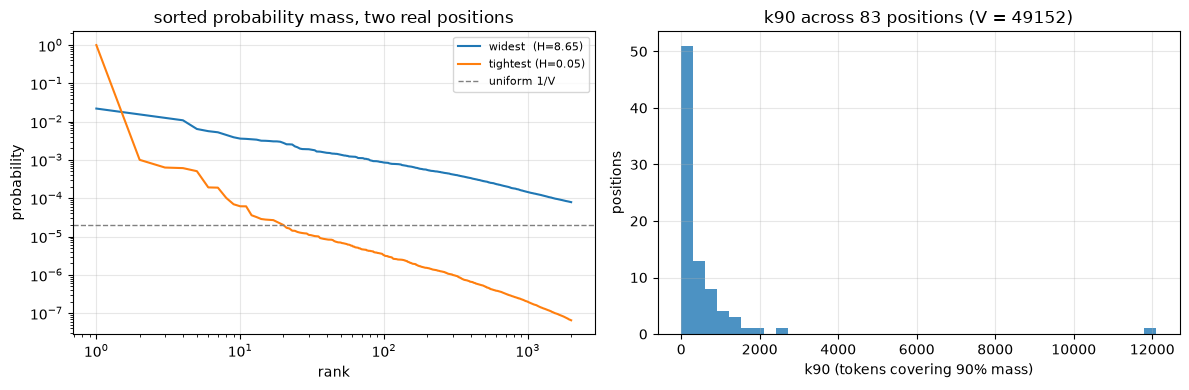

In [ ]:
import matplotlib.pyplot as plt

P = torch.softmax(Z, dim=-1)
H_all = -(P * torch.log(P.clamp_min(1e-30))).sum(-1)
srt = torch.sort(P, dim=-1, descending=True).values
k90_all = (torch.cumsum(srt, -1) < 0.90).sum(-1) + 1
top1_all = srt[:, 0]

print(f"across {T} positions (T = 1.0):")
for nm, v in [("top1", top1_all), ("H (nats)", H_all),
              ("exp(H)", H_all.exp()), ("k90", k90_all.float())]:
    print(f"  {nm:9s} median {v.median():10.3f} | min {v.min():9.3f} | max {v.max():10.3f}")
print(f"\nV = {V};  median exp(H)/V = {float(H_all.exp().median())/V:.5f};"
      f"  median k90/V = {float(k90_all.float().median())/V:.5f}")
print(f"median k90 / median exp(H) = {float(k90_all.float().median())/float(H_all.exp().median()):.1f}x"
      f"   <- tail weight: how far the count exceeds the mass-weighted width")

hi, lo = int(H_all.argmax()), int(H_all.argmin())
print(f"widest   position {hi}: H {H_all[hi]:.3f}, k90 {int(k90_all[hi])}, top1 {top1_all[hi]:.4f}")
print(f"tightest position {lo}: H {H_all[lo]:.3f}, k90 {int(k90_all[lo])}, top1 {top1_all[lo]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(np.arange(1, 2001), srt[hi, :2000].numpy(), label=f"widest  (H={H_all[hi]:.2f})")
ax[0].loglog(np.arange(1, 2001), srt[lo, :2000].numpy(), label=f"tightest (H={H_all[lo]:.2f})")
ax[0].axhline(1.0 / V, ls="--", c="gray", lw=1, label="uniform 1/V")
ax[0].set_xlabel("rank"); ax[0].set_ylabel("probability")
ax[0].set_title("sorted probability mass, two real positions")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].hist(k90_all.numpy(), bins=40, color="tab:blue", alpha=0.8)
ax[1].set_xlabel("k90 (tokens covering 90% mass)"); ax[1].set_ylabel("positions")
ax[1].set_title(f"k90 across {T} positions (V = {V})"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")

print("Tight = recognized Q/A in exam, Wide : stuck guessing b/w arbitrary number of answers")

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | shift invariance holds to float noise | ≤ 1e-7 | 0.000 | ✅ Holds |
| C2 | naive softmax overflows, stable form does not | `nan` once shifted max > 88.72 | infinte vs 25.135 | ✅ Holds |
| C3 | three routes to cross-entropy agree | ≤ 1e-6 | < 4.7e-7| ✅ Holds |
| C4 | entropy strictly increasing in `T`, ceiling `log V = 10.803` | monotone, within 0.05 | strictly monotonic | ✅ Holds |
| C5 | real distributions are far from uniform | median `k90` < 50, median `exp(H)` < 200 | 77 & 200 toks| ✅ Holds |

*(Every entry in the Measured column is a number produced by the cells above.)*

## Discussion and verdict

**

**Why it matters.** The identities established here are the contract the rest of the repository trades on: perplexity is `exp` of the mean of the quantity measured in the cross-entropy cell; every truncation operator is a mask applied to the sorted vector measured in the shape cell; temperature is the one operator acting *before* the mask, changing the very curve the mask cuts. Nothing downstream introduces new probability machinery — it only rearranges these pieces.

**Honesty note.** One model, one passage, final-layer logits, float32. The distributional numbers (`k90`, `exp(H)`) describe this text under this model; the identities (shift invariance, the cross-entropy equality, the entropy limits) are properties of the map and hold for any logit vector.

**Where the next study goes.** Cross-entropy is measured per position here; the next study averages it into perplexity and asks the question averaging raises — what does the reported number depend on besides the model? Tokenizer, context window, and stride all enter, and each one moves it.

## References

1. Bridle, J. S. (1990). *Probabilistic Interpretation of Feedforward Classification Network Outputs*. Neurocomputing, NATO ASI Series.
2. Bengio, Y., Ducharme, R., Vincent, P., Jauvin, C. (2003). *A Neural Probabilistic Language Model*. JMLR 3:1137–1155.
3. Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning*, MIT Press — §4.1 (numerical stability), §6.2 (softmax output units).
4. Hinton, G., Vinyals, O., Dean, J. (2015). *Distilling the Knowledge in a Neural Network*. arXiv:1503.02531.
5. Guo, C., Pleiss, G., Sun, Y., Weinberger, K. (2017). *On Calibration of Modern Neural Networks*. arXiv:1706.04599.
6. Holtzman, A., Buys, J., Du, L., Forbes, M., Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. arXiv:1904.09751.
7. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.